In [1]:
import pandas as pd
import sys
from pathlib import Path

# The notebook runs from notebooks/, so climb one level to the project root
# and add it to sys.path so "src.support..." becomes importable.
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.support.EDA_utils import load_all, eda_report

RAW_DIR = PROJECT_ROOT / "data" / "raw"

In [2]:
df_adzuna = load_all(RAW_DIR)
print(df_adzuna.shape)   
df_adzuna.head()


(951, 18)


,id,title,company,category_label,category_tag,location_name,salary_min,salary_max,salary_is_predicted,latitude,longitude,contract_type,contract_time,created,description,redirect_url,search_category,source_page
0,5768359579,"Senior Solution Consultant, UKG (WFD & WFC)",Strada,Trabajos en consultoría,consultancy-jobs,"Madrid, Comunidad de Madrid",NaN,NaN,0,40.416700,3.703250,None,None,2026-06-18T22:22:10Z,"Senior Solution Consultant, UKG (WFD & WFC) St...",https://www.adzuna.es/details/5768359579?utm_m...,consultancy-jobs,p1
1,5784936570,Senior Product Manager - Money (Barcelona),Heetch,Trabajos en consultoría,consultancy-jobs,"Barcelona, Cataluña",65000.0,85000.0,0,41.385100,2.173400,None,None,2026-07-02T06:46:55Z,"Executive Summary Own the vision, strategy and...",https://www.adzuna.es/details/5784936570?utm_m...,consultancy-jobs,p1
2,5781764254,"Director, Viral Vector BD — Gene Therapy Partn...",SK pharmteco,Trabajos en consultoría,consultancy-jobs,"Boiro, A Coruña",70000.0,90000.0,0,42.647057,-8.882718,None,None,2026-06-30T06:43:25Z,SK pharmteco busca un Director de Desarrollo d...,https://www.adzuna.es/details/5781764254?utm_m...,consultancy-jobs,p1
3,5780809431,Director of Assisted Channels Transformation,BANCO SANTANDER,Trabajos en consultoría,consultancy-jobs,"Madrid, Comunidad de Madrid",70000.0,90000.0,0,40.416700,3.703250,None,None,2026-06-29T06:41:35Z,BANCO SANTANDER is seeking a Project Director ...,https://www.adzuna.es/details/5780809431?utm_m...,consultancy-jobs,p1
4,5781765668,Global Expansion Director: Market Strategy,D&M asesores consultores,Trabajos en consultoría,consultancy-jobs,"Madrid, Comunidad de Madrid",60000.0,80000.0,0,40.416700,3.703250,None,None,2026-06-30T06:44:37Z,D&M asesores consultores en Madrid busca un pr...,https://www.adzuna.es/details/5781765668?utm_m...,consultancy-jobs,p1


In [3]:
eda_report(df_adzuna)

EDA REPORT

DATASET SHAPE
Rows: 951, Columns: 18

DATA TYPES
id                      object
title                   object
company                 object
category_label          object
category_tag            object
location_name           object
salary_min             float64
salary_max             float64
salary_is_predicted     object
latitude               float64
longitude              float64
contract_type           object
contract_time           object
created                 object
description             object
redirect_url            object
search_category         object
source_page             object
dtype: object

MISSING VALUES (NaN = field absent in Adzuna response)
contract_type    951
contract_time    924
salary_max       395
salary_min       395
latitude         161
longitude        161
company           91
dtype: int64

Missing as % of rows:
contract_type    100.00
contract_time     97.16
salary_max        41.54
salary_min        41.54
latitude          16.93
longitud

### Salary presence per category

In [4]:
# Does the 58.46% global salary presence hold uniformly per category, or does it hide differences?
by_cat = df_adzuna.groupby("search_category").agg(
    total=("id", "size"),
    with_salary=("salary_min", lambda s: s.notna().sum()),
)
by_cat["pct_with_salary"] = (by_cat["with_salary"] / by_cat["total"] * 100).round(1)
print(by_cat)

                  total  with_salary  pct_with_salary
search_category                                      
consultancy-jobs    250          176             70.4
hr-jobs             250          108             43.2
it-jobs             250          131             52.4
legal-jobs          201          141             70.1


In [5]:
# Round, repeated salary_min values suggest an Adzuna-derived estimate; dispersed values suggest employer-stated.
postings_with_salary = df_adzuna[df_adzuna["salary_min"].notna()].copy()

print("Postings with salary:", len(postings_with_salary))
print("Distinct salary_min values:", postings_with_salary["salary_min"].nunique())
print()
print("Most common salary_min values:")
print(postings_with_salary["salary_min"].value_counts().head(15))

Postings with salary: 556
Distinct salary_min values: 62

Most common salary_min values:
salary_min
70000.0     111
60000.0     103
80000.0      72
100000.0     65
90000.0      36
120000.0     32
65000.0      16
40000.0      16
50000.0      11
30000.0       8
35000.0       7
25000.0       7
45000.0       6
27000.0       5
24000.0       4
Name: count, dtype: int64


In [6]:
print(df_adzuna.columns.tolist())
print("---")
print(df_adzuna.dtypes)

['id', 'title', 'company', 'category_label', 'category_tag', 'location_name', 'salary_min', 'salary_max', 'salary_is_predicted', 'latitude', 'longitude', 'contract_type', 'contract_time', 'created', 'description', 'redirect_url', 'search_category', 'source_page']
---
id                      object
title                   object
company                 object
category_label          object
category_tag            object
location_name           object
salary_min             float64
salary_max             float64
salary_is_predicted     object
latitude               float64
longitude              float64
contract_type           object
contract_time           object
created                 object
description             object
redirect_url            object
search_category         object
source_page             object
dtype: object


In [7]:
# EDA closure — six open questions blocking the BigQuery schema.

# --- 1. DUPLICATES (determines the real denominator) ---
total_records = len(df_adzuna)
unique_posting_ids = df_adzuna["id"].nunique()
duplicated_records = total_records - unique_posting_ids

print(f"Total records: {total_records}")
print(f"Unique posting ids: {unique_posting_ids}")
print(f"Duplicated records: {duplicated_records}")

if duplicated_records > 0:
    duplicated_ids = df_adzuna[df_adzuna["id"].duplicated(keep=False)]["id"].unique()
    duplicated_subset = df_adzuna[df_adzuna["id"].isin(duplicated_ids)]

    # Cross-category overlap (same posting under two categories) is a market finding, not a defect.
    categories_per_duplicated_id = duplicated_subset.groupby("id")["search_category"].nunique()
    print(f"Ids in more than one category: {(categories_per_duplicated_id > 1).sum()}")
    print(f"Ids duplicated within a single category: {(categories_per_duplicated_id == 1).sum()}")

    overlapping_ids = categories_per_duplicated_id[categories_per_duplicated_id > 1].index
    print(
        df_adzuna[df_adzuna["id"].isin(overlapping_ids)]
        .groupby("id")["search_category"]
        .apply(lambda categories: " + ".join(sorted(categories.unique())))
        .value_counts()
    )

    # Pagination overlap within one category is an extraction defect, not a market finding.
    pagination_ids = categories_per_duplicated_id[categories_per_duplicated_id == 1].index
    if len(pagination_ids) > 0:
        print("\nPagination overlap detected — extraction defect:")
        print(
            df_adzuna[df_adzuna["id"].isin(pagination_ids)]
            .groupby(["search_category", "source_page"])
            .size()
        )

# --- 2. SALARY PROVENANCE ---
# dtype is object, so values are likely strings, not booleans — relevant for the BigQuery type decision.
print(f"\nsalary_is_predicted raw values: {df_adzuna['salary_is_predicted'].unique()}")
print(df_adzuna["salary_is_predicted"].value_counts(dropna=False))

# Does the flag only appear where a salary value exists?
postings_with_salary = df_adzuna["salary_min"].notna()
print(f"\nPostings with salary_min: {postings_with_salary.sum()} "
      f"({postings_with_salary.mean() * 100:.1f}%)")
print(pd.crosstab(
    postings_with_salary,
    df_adzuna["salary_is_predicted"].fillna("ABSENT"),
    rownames=["has_salary_min"],
))

# --- 3. LOCATION (already flat — confirm granularity available) ---
print(f"\nLocation samples: {df_adzuna['location_name'].head(3).to_list()}")
print(f"Unique locations: {df_adzuna['location_name'].nunique()}")
print(f"Coordinates present: {df_adzuna['latitude'].notna().mean() * 100:.1f}%")

# --- 4. DATE FIELD (string -> TIMESTAMP; documents Timeliness) ---
print(f"\nDate samples: {df_adzuna['created'].head(3).to_list()}")
parsed_creation_dates = pd.to_datetime(df_adzuna["created"], errors="coerce", utc=True)
print(f"Unparseable dates: {parsed_creation_dates.isna().sum()}")
print(f"Range: {parsed_creation_dates.min()} to {parsed_creation_dates.max()}")

# --- 5. COMPANY CARDINALITY (Consistency finding; cleaning is staging) ---
# Postings without a company are likely anonymous agency listings — absence is itself a finding.
print(f"\nUnique company names: {df_adzuna['company'].nunique()}")
print(f"Postings without company: {df_adzuna['company'].isna().sum()}")
print(df_adzuna["company"].value_counts().head(15))

# --- 6. CONTRACT FIELDS (confirm structural emptiness) ---
for column in ["contract_type", "contract_time"]:
    print(f"{column}: {df_adzuna[column].notna().mean() * 100:.1f}% present "
          f"| values: {df_adzuna[column].dropna().unique()[:5]}")

Total records: 951
Unique posting ids: 947
Duplicated records: 4
Ids in more than one category: 0
Ids duplicated within a single category: 4
Series([], Name: count, dtype: int64)

Pagination overlap detected — extraction defect:
search_category  source_page
it-jobs          p1             4
                 p3             2
                 p5             2
dtype: int64

salary_is_predicted raw values: ['0']
salary_is_predicted
0    951
Name: count, dtype: int64

Postings with salary_min: 556 (58.5%)
salary_is_predicted    0
has_salary_min          
False                395
True                 556

Location samples: ['Madrid, Comunidad de Madrid', 'Barcelona, Cataluña', 'Boiro, A Coruña']
Unique locations: 184
Coordinates present: 83.1%

Date samples: ['2026-06-18T22:22:10Z', '2026-07-02T06:46:55Z', '2026-06-30T06:43:25Z']
Unparseable dates: 0
Range: 2024-03-08 10:59:01+00:00 to 2026-07-06 13:42:06+00:00

Unique company names: 474
Postings without company: 91
company
Expert Executive 

In [8]:
# EDA closure — two findings not covered by the previous cell.

# --- UNIT INCONSISTENCY (Validity) ---
# Values below a plausible annual floor are almost certainly hourly rates, undeclared.
implausible_annual_salaries = df_adzuna[
    postings_with_salary & (df_adzuna["salary_min"] < 12000)
]
print(f"Salaries below 12000 (likely hourly): {len(implausible_annual_salaries)}")
print(implausible_annual_salaries[["title", "salary_min", "salary_max"]].head(10))

# --- REDUNDANT CATEGORY COLUMNS ---
# category_tag (Adzuna's) vs search_category (ours) — if they never diverge, one is redundant.
category_mismatch = df_adzuna[df_adzuna["category_tag"] != df_adzuna["search_category"]]
print(f"\nRows where category_tag != search_category: {len(category_mismatch)}")

Salaries below 12000 (likely hourly): 11
                                        title  salary_min  salary_max
318                        Contract Dummy Job       360.0       480.0
370                       Interim People Lead      6875.0     75000.0
376                           Job for testing       360.0       480.0
402          Chargé de sélection en stage F/H       694.0       945.0
410                Técnico de formación (H/M)       300.0       312.0
457      Talent Acquisition & Team Specialist        30.0        35.0
458        Commercial sédentaire en stage F/H      8328.0     11340.0
595  Product Engineer (Accounting and Ledger)        60.0        69.0
632                            Technical Lead      1000.0     60000.0
647                 Forward Deployed Engineer       150.0       175.0

Rows where category_tag != search_category: 0


In [9]:
# Description-independent diagnostics: magnitude, gap, and ratio.
low_salary_postings = df_adzuna[
    postings_with_salary & (df_adzuna["salary_min"] < 12000)
].copy()
print(f"Affected postings: {len(low_salary_postings)}")

# Gap test: a clean break before the normal range supports a distinct unit regime.
print(df_adzuna["salary_min"].dropna().sort_values().head(25).to_list())

# Ratio test: a truncated annual band preserves its min/max proportions.
low_salary_postings["min_max_ratio"] = (
    low_salary_postings["salary_max"] / low_salary_postings["salary_min"]
).round(2)
print(low_salary_postings[["title", "salary_min", "salary_max",
                           "min_max_ratio"]].to_string())

Affected postings: 11
[28.0, 30.0, 60.0, 150.0, 300.0, 360.0, 360.0, 694.0, 1000.0, 6875.0, 8328.0, 16200.0, 18000.0, 22000.0, 22000.0, 22000.0, 24000.0, 24000.0, 24000.0, 24000.0, 25000.0, 25000.0, 25000.0, 25000.0, 25000.0]
                                        title  salary_min  salary_max  min_max_ratio
318                        Contract Dummy Job       360.0       480.0           1.33
370                       Interim People Lead      6875.0     75000.0          10.91
376                           Job for testing       360.0       480.0           1.33
402          Chargé de sélection en stage F/H       694.0       945.0           1.36
410                Técnico de formación (H/M)       300.0       312.0           1.04
457      Talent Acquisition & Team Specialist        30.0        35.0           1.17
458        Commercial sédentaire en stage F/H      8328.0     11340.0           1.36
595  Product Engineer (Accounting and Ledger)        60.0        69.0           1.15
632      

In [10]:
# Manual inspection via redirect_url is a legitimate check when the API doesn't expose the raw value.
for row_index, posting in low_salary_postings.iterrows():
    print(f"{posting['salary_min']:.0f} - {posting['salary_max']:.0f} | {posting['title'][:60]}")
    print(posting["redirect_url"])
    print()

360 - 480 | Contract Dummy Job
https://www.adzuna.es/details/4598654636?utm_medium=api&utm_source=62482c4f

6875 - 75000 | Interim People Lead
https://www.adzuna.es/details/5713285096?utm_medium=api&utm_source=62482c4f

360 - 480 | Job for testing
https://www.adzuna.es/details/4598654572?utm_medium=api&utm_source=62482c4f

694 - 945 | Chargé de sélection en stage F/H
https://www.adzuna.es/details/5508334035?utm_medium=api&utm_source=62482c4f

300 - 312 | Técnico de formación (H/M)
https://www.adzuna.es/details/5756924358?utm_medium=api&utm_source=62482c4f

30 - 35 | Talent Acquisition & Team Specialist
https://www.adzuna.es/details/5701336023?utm_medium=api&utm_source=62482c4f

8328 - 11340 | Commercial sédentaire en stage F/H
https://www.adzuna.es/details/4977806594?utm_medium=api&utm_source=62482c4f

60 - 69 | Product Engineer (Accounting and Ledger)
https://www.adzuna.es/details/5747730624?utm_medium=api&utm_source=62482c4f

1000 - 60000 | Technical Lead
https://www.adzuna.es/detail

In [11]:
# Locale hypothesis: Spanish thousands separator ("28.000 €") parsed as an English decimal (28.0).
# Annual salaries never have decimals, so non-integer values would be the signature of misparsing.
salary_values = df_adzuna["salary_min"].dropna()

non_integer_salaries = salary_values[salary_values % 1 != 0]
print(f"Non-integer salary_min values: {len(non_integer_salaries)}")
print(sorted(non_integer_salaries.unique()))

print("\nLowest 30 values:")
print(sorted(salary_values.unique())[:30])

# Reconstruction check: the low cluster x1000 should land inside the observed normal range.
low_salary_values = salary_values[salary_values < 12000]
print(f"\nLow cluster x1000 range: {low_salary_values.min() * 1000:.0f} "
      f"to {low_salary_values.max() * 1000:.0f}")

Non-integer salary_min values: 0
[]

Lowest 30 values:
[np.float64(28.0), np.float64(30.0), np.float64(60.0), np.float64(150.0), np.float64(300.0), np.float64(360.0), np.float64(694.0), np.float64(1000.0), np.float64(6875.0), np.float64(8328.0), np.float64(16200.0), np.float64(18000.0), np.float64(22000.0), np.float64(24000.0), np.float64(25000.0), np.float64(25541.0), np.float64(26000.0), np.float64(27000.0), np.float64(27600.0), np.float64(28000.0), np.float64(30000.0), np.float64(31500.0), np.float64(33000.0), np.float64(35000.0), np.float64(35682.0), np.float64(36000.0), np.float64(37440.0), np.float64(38000.0), np.float64(40000.0), np.float64(40500.0)]

Low cluster x1000 range: 28000 to 8328000


In [ ]:
# Row count below the legal annual floor — the exclusion decision depends on how many rows it removes.
SPANISH_MINIMUM_ANNUAL_WAGE = 17094  
below_minimum_wage = postings_with_salary & (df_adzuna["salary_min"] < SPANISH_MINIMUM_ANNUAL_WAGE)

print(f"Postings with salary: {postings_with_salary.sum()}")
print(f"Below minimum wage: {below_minimum_wage.sum()} "
      f"({below_minimum_wage.sum() / postings_with_salary.sum() * 100:.1f}%)")

# Effect of the exclusion on the headline figure, so the bias is quantified rather than assumed negligible.
print(f"\nMean with all values:      {df_adzuna['salary_min'].mean():,.0f}")
print(f"Mean excluding below SMI:  {df_adzuna.loc[~below_minimum_wage, 'salary_min'].mean():,.0f}")

print(f"\nAffected by category:")
print(df_adzuna.loc[below_minimum_wage, "search_category"].value_counts())

### Extended EDA — visualizations and remaining dimensions

Gaps identified in the initial pass: no plots, only the low end of the salary range was checked, no per-category salary levels, `company`/`location` consistency was measured but not inspected, and `created` had no time-distribution beyond min/max.

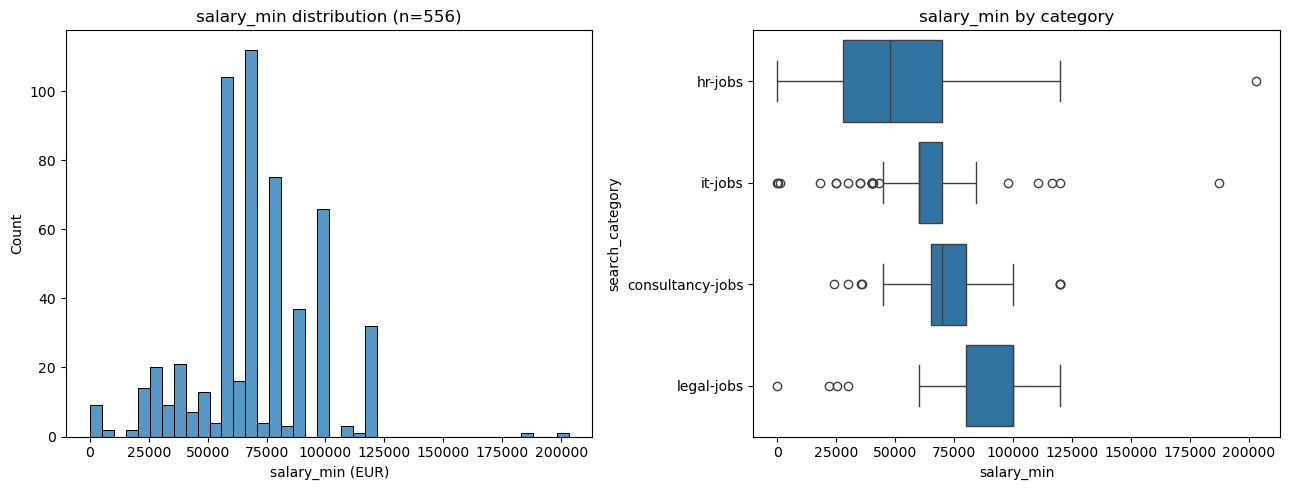

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual read of what the tables above already show: shape, spread, and per-category level.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df_adzuna.loc[postings_with_salary, "salary_min"], bins=40, ax=axes[0])
axes[0].set_title("salary_min distribution (n=556)")
axes[0].set_xlabel("salary_min (EUR)")

order = df_adzuna.groupby("search_category")["salary_min"].median().sort_values().index
sns.boxplot(data=df_adzuna, x="salary_min", y="search_category", order=order, ax=axes[1])
axes[1].set_title("salary_min by category")

plt.tight_layout()
plt.show()

In [13]:
# Salary LEVEL per category — only presence was checked earlier, not the actual figures.
salary_by_cat = df_adzuna.groupby("search_category")["salary_min"].agg(
    ["count", "mean", "median", "min", "max"]
).round(0)
print(salary_by_cat)

                  count     mean    median      min       max
search_category                                              
consultancy-jobs    176  72269.0   70000.0  24000.0  120000.0
hr-jobs             108  50916.0   47880.0     30.0  203112.0
it-jobs             131  62890.0   60000.0     60.0  187200.0
legal-jobs          141  92713.0  100000.0     28.0  120000.0


In [14]:
# The low end got a full investigation (hourly-rate hypothesis, confirmed). Check the high end with the same rigor.
print("Top 15 salary_min:", df_adzuna["salary_min"].dropna().sort_values(ascending=False).head(15).to_list())
print("Top 15 salary_max:", df_adzuna["salary_max"].dropna().sort_values(ascending=False).head(15).to_list())

# Above 150k there's a clean drop to the 120k cluster — only these two sit outside it.
high_salary_postings = df_adzuna[postings_with_salary & (df_adzuna["salary_min"] > 150000)]
print(f"\nPostings with salary_min > 150000: {len(high_salary_postings)}")
print(high_salary_postings[["title", "company", "salary_min", "salary_max"]].to_string())

Top 15 salary_min: [203112.0, 187200.0, 120000.0, 120000.0, 120000.0, 120000.0, 120000.0, 120000.0, 120000.0, 120000.0, 120000.0, 120000.0, 120000.0, 120000.0, 120000.0]
Top 15 salary_max: [395200.0, 243288.0, 217696.0, 180000.0, 180000.0, 180000.0, 180000.0, 180000.0, 180000.0, 180000.0, 180000.0, 180000.0, 180000.0, 166270.0, 160000.0]

Postings with salary_min > 150000: 2
                                                      title       company  salary_min  salary_max
463    Líder de Operaciones y Servicio al Cliente (Turismo)  RAMKA MOTORS    203112.0    243288.0
597  M&A Consultant - AI Trainer - Freelance - 8-20hrs/week      10x Team    187200.0    395200.0


In [15]:
# Validity check never run explicitly: can salary_min exceed salary_max?
inverted_range = df_adzuna["salary_min"] > df_adzuna["salary_max"]
print(f"Postings with salary_min > salary_max: {inverted_range.sum()}")

Postings with salary_min > salary_max: 0


In [16]:
# Confirm the 4 duplicate ids are the SAME posting reappearing on a later page, not an id collision
# between different postings — compares every column except source_page.
dup_ids = df_adzuna[df_adzuna["id"].duplicated(keep=False)]["id"].unique()
cols_except_page = [c for c in df_adzuna.columns if c != "source_page"]
for posting_id in dup_ids:
    rows = df_adzuna[df_adzuna["id"] == posting_id][cols_except_page]
    identical = rows.nunique(dropna=False).eq(1).all()
    print(f"{posting_id}: identical except source_page = {identical}")

5697039277: identical except source_page = True
5768358657: identical except source_page = True
5768353989: identical except source_page = True
5788551290: identical except source_page = True


In [17]:
# Consistency: same company under different spellings (case/whitespace) would inflate the 474 unique count.
companies = df_adzuna["company"].dropna()
normalized = companies.str.lower().str.strip().str.replace(r"[^a-z0-9]+", "", regex=True)
variant_counts = companies.groupby(normalized).nunique()
variants = variant_counts[variant_counts > 1]

print(f"Normalized keys with >1 raw spelling: {len(variants)}")
for key in variants.index:
    print(f"  {list(companies[normalized == key].unique())}")

Normalized keys with >1 raw spelling: 6
  ['dLocal', 'Dlocal']
  ['domestiko.com', 'Domestiko.com']
  ['Erm', 'ERM']
  ['Expert Executive Recruiters ', 'Expert Executive Recruiters']
  ['Neoris', 'NEORIS']
  ['thexpeople', 'Thexpeople']


In [18]:
# location_name granularity is not uniform: some rows carry only "City, Region", others just a
# country/region-level string (no comma) — that must be handled before any "top city" analysis.
locations = df_adzuna["location_name"].dropna()
no_comma = locations[~locations.str.contains(",")]
print(f"Locations without a comma (country/region-level only): {len(no_comma)}")
print(no_comma.value_counts().head(5))

top_cities = locations.str.split(",").str[0].str.strip().value_counts().head(10)
print(f"\nTop cities:\n{top_cities}")
print(f"\nMadrid + Barcelona share: {top_cities.reindex(['Madrid', 'Barcelona']).sum() / len(locations) * 100:.1f}%")

Locations without a comma (country/region-level only): 307
location_name
España                    136
Madrid                     73
Barcelona                  47
Valencia                    8
Santa Cruz de Tenerife      8
Name: count, dtype: int64

Top cities:
location_name
Madrid                    262
Barcelona                 138
España                    136
Valencia                   26
Sevilla                    14
Santa Cruz de Tenerife     12
Málaga                     11
Vitoria-Gasteiz            10
A Coruña                   10
Getafe                     10
Name: count, dtype: int64

Madrid + Barcelona share: 42.1%


Postings older than 90 days at extraction time: 161 (16.9%)


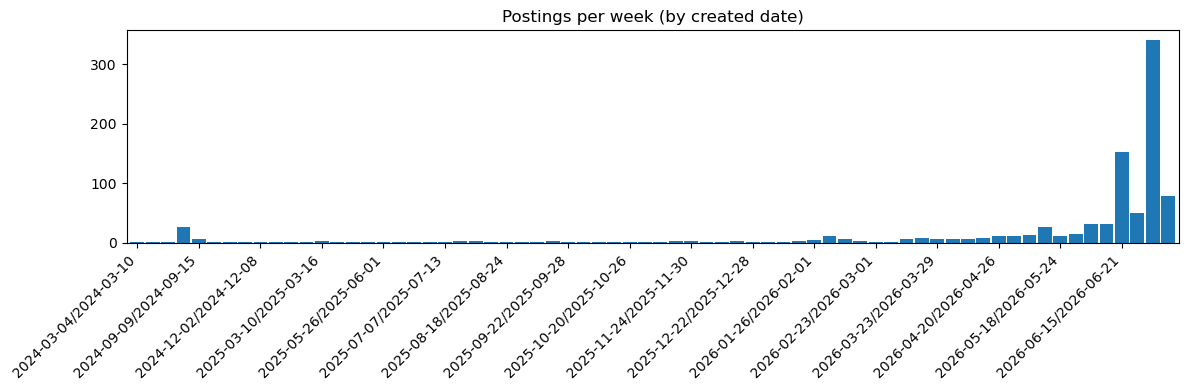

In [19]:
# The date range (2024-03 to 2026-07) was reported earlier but never the shape inside it —
# is volume concentrated near the extraction date, or is there a long tail of old postings?
creation_dates = pd.to_datetime(df_adzuna["created"], utc=True)
weekly_counts = creation_dates.dt.tz_localize(None).dt.to_period("W").value_counts().sort_index()

old_cutoff = creation_dates.max() - pd.Timedelta(days=90)
postings_older_than_90d = (creation_dates < old_cutoff).sum()
print(f"Postings older than 90 days at extraction time: {postings_older_than_90d} "
      f"({postings_older_than_90d / len(creation_dates) * 100:.1f}%)")

fig, ax = plt.subplots(figsize=(12, 4))
weekly_counts.plot(kind="bar", ax=ax, width=0.9)
ax.set_title("Postings per week (by created date)")
ax.set_xlabel("")
ax.set_xticks(range(0, len(weekly_counts), 4))
ax.set_xticklabels([str(p) for p in weekly_counts.index[::4]], rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [20]:
# legal-jobs returned 201 postings vs 250 for the other three — page-level counts show why:
# it's exhaustion (fewer available postings), not a truncated extraction.
print(df_adzuna.groupby(["search_category", "source_page"]).size().unstack(fill_value=0))

source_page       p1  p2  p3  p4  p5
search_category                     
consultancy-jobs  50  50  50  50  50
hr-jobs           50  50  50  50  50
it-jobs           50  50  50  50  50
legal-jobs        50  50  50  50   1
